In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

# Thirty-two ionizable groups on one molecule (Figure 13.6-7)

A protein is an amino acid problem with the count turned up. Hen egg white lysozyme has
**32 ionizable groups** -- carboxyls on aspartate and glutamate, ammoniums on lysine,
guanidiniums on arginine, an imidazole on its one histidine, three phenols on tyrosine,
and the two chain ends -- and its net charge runs from $+19$ in strong acid to $-13$ in
strong base.

Nothing new is needed. Section 13.6's Eq. 13.6-3 already handled several ionizations on one
molecule; a protein just has more terms. Each group is treated as **independent**: its
p$K$ does not depend on whether its neighbors have ionized. That is the approximation,
and it is worth being explicit about, because it is the one a real protein violates.

$$\text{charge}(\mathrm{pH})=\sum_{\text{cationic}}\frac{n_i}{1+10^{\,\mathrm{pH}-\mathrm{p}K_i}}
-\sum_{\text{anionic}}\frac{n_j}{1+10^{\,\mathrm{p}K_j-\mathrm{pH}}}$$

A cationic group carries $+1$ while it holds its proton; an anionic group carries $-1$ once
it loses one. Both terms fall with pH, so **the charge on any protein decreases
monotonically with pH** -- which is why an isoelectric point exists at all and is unique.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst
August 2026


In [2]:
import sys; sys.path.append("..")
import numpy as np
import matplotlib.pyplot as plt

from thermo.ionization import LYSOZYME, protein_charge, isoelectric_point, IonizableGroup
from thermo.charts import use_book_style

use_book_style()

pH = np.linspace(0.0, 14.0, 1401)

print(f"  {'group':<28} {'n':>3}  {'pK':>5}   sign when charged")
for g in LYSOZYME:
    print(f"  {g.name:<28} {g.count:3d}  {g.pK:5.2f}   {'+1 protonated' if g.cationic else '-1 deprotonated'}")
n_cat = sum(g.count for g in LYSOZYME if g.cationic)
n_an = sum(g.count for g in LYSOZYME if not g.cationic)
print(f"\n  {n_cat} basic + {n_an} acidic = {n_cat + n_an} groups"
      f"   [Sec. 13.6: 19 basic, 13 acid, 32 ionizable]")


  group                          n     pK   sign when charged
  alpha-amino (N terminus)       1   7.70   +1 protonated
  histidine                      1   6.00   +1 protonated
  lysine                         6  10.50   +1 protonated
  arginine                      11  12.50   +1 protonated
  alpha-carboxyl (C term.)       1   3.10   -1 deprotonated
  aspartic acid                  7   3.90   -1 deprotonated
  glutamic acid                  2   4.30   -1 deprotonated
  tyrosine                       3  10.10   -1 deprotonated

  19 basic + 13 acidic = 32 groups   [Sec. 13.6: 19 basic, 13 acid, 32 ionizable]


## The book's pI is right, and it is this model that falls short

Section 13.6 prints **no p$K$ values** for lysozyme. It gives three facts -- 32 groups,
"19 basic groups and 13 acid groups", and a charge from $+19$ to $-13$ -- and a curve.

The composition above is the one that satisfies all three: the amino acid counts of hen egg
white lysozyme with standard model p$K$s for free residues. The end values come out right
because they are pure counting. **The isoelectric point does not: this model gives 10.87.**

That is not a defect in the book. The measured pI of hen egg white lysozyme is
**11.0 to 11.35**, so the 11.2 the section quotes sits inside the accepted range, and the
model is **0.1 to 0.5 units low**. The pI is a property of the sequence, and it moves with
the source:

| lysozyme | measured pI |
|---|---|
| hen egg white | 11.0 -- 11.35 |
| human | 10.5 -- 11.0 |
| bacterial (*Streptomyces* spp.) | about 9.5 |

**Why the model is low is the approximation named at the top of this notebook.** Treating
the 32 sites as independent, with the p$K$ of a *free* amino acid, ignores two things that
both push the pI up: a buried group sits in a low-dielectric interior and holds its proton
longer, and removing a proton from a protein that is still net positive is easier than the
free-residue p$K$ implies. Add either effect and the curve flattens and the zero-crossing
moves right -- that is `Your turn` question 2.

**So the gap is left in place deliberately, and it is a result rather than an embarrassment**:
an independent-site model built only from residue counts lands within half a pH unit of a
measured protein pI, and the half unit is the interaction it left out. Nudging a tyrosine
p$K$ to close it would hide the one thing worth seeing.


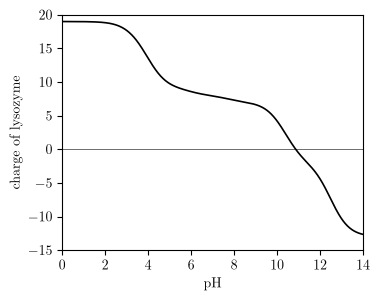

  charge at pH  0  =  +19.00   book: +19
  charge at pH  7  =   +7.93
  charge at pH 14  =  -12.66   book: -13 (the figure reads about -12)
  isoelectric point = 10.87          text: 11.2   measured: 11.0 to 11.35
  the model is 0.33 below the section's value and 0.13 below the bottom of the measured range


In [3]:
charge = protein_charge(pH)
pI = isoelectric_point()

# The print figure carries NO pI annotation. The model's zero-crossing is 10.87 and the
# section's text says 11.2 -- a measured value -- so labeling the computed number on the
# art would print a disagreement the reader cannot resolve from the page. The curve is the
# claim; the number belongs in the text.
fig, ax = plt.subplots(figsize=(3.9, 3.1))
ax.plot(pH, charge, "-", color="k", lw=1.2)
ax.axhline(0.0, color="k", lw=0.4, zorder=0)
ax.set_xlabel("pH"); ax.set_ylabel("charge of lysozyme")
ax.set_xlim(0, 14); ax.set_ylim(-15, 20)
ax.set_xticks(range(0, 15, 2)); ax.set_yticks([-15, -10, -5, 0, 5, 10, 15, 20])
fig.tight_layout(); plt.show()

print(f"  charge at pH  0  = {protein_charge(0.0):+7.2f}   book: +19")
print(f"  charge at pH  7  = {protein_charge(7.0):+7.2f}")
print(f"  charge at pH 14  = {protein_charge(14.0):+7.2f}   book: -13 (the figure reads about -12)")
print(f"  isoelectric point = {pI:.2f}          text: 11.2   measured: 11.0 to 11.35")
print(f"  the model is {11.2 - pI:.2f} below the section's value and "
      f"{11.0 - pI:.2f} below the bottom of the measured range")


The printed Fig. 13.6-7 is drawn over a **gray gradient background**. The 6e's figure
art is pure black ink on white, with families separated by weight, dash and geometry
rather than by tint [[black-not-gray]], so the redraw above drops it.

## Where each step comes from

The value of decomposing the sum is that the curve stops being a curve and becomes a
census. Every shoulder in Fig. 13.6-7 is a group -- or a set of groups -- letting go.


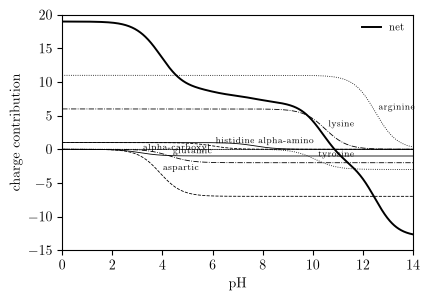

  the steps in the net curve, read as derivatives:
    a shoulder at pH  3.95, losing 5.27 charges per pH unit
    a shoulder at pH  7.71, losing 0.67 charges per pH unit
    a shoulder at pH 10.42, losing 5.15 charges per pH unit
    a shoulder at pH 12.48, losing 6.50 charges per pH unit


In [4]:
fig2, ax = plt.subplots(figsize=(4.4, 3.1))
ax.plot(pH, charge, "-", color="k", lw=1.4, label="net")
for g, ls in zip(LYSOZYME, ["-", "--", "-.", ":", "-", "--", "-.", ":"]):
    ax.plot(pH, g.charge(pH), ls, color="k", lw=0.6)
    xt = g.pK
    ax.annotate(g.name.split()[0], (xt, g.charge(xt)), fontsize=5.5,
                textcoords="offset points", xytext=(2, 2))
ax.axhline(0.0, color="k", lw=0.4, zorder=0)
ax.set_xlabel("pH"); ax.set_ylabel("charge contribution")
ax.set_xlim(0, 14); ax.set_ylim(-15, 20)
ax.legend(frameon=False, fontsize=7, loc="upper right")
fig2.tight_layout(); plt.show()

print("  the steps in the net curve, read as derivatives:")
d = -np.gradient(charge, pH)
for i in range(1, len(pH) - 1):
    if d[i] > d[i - 1] and d[i] > d[i + 1] and d[i] > 0.5:
        print(f"    a shoulder at pH {pH[i]:5.2f}, losing {d[i]:.2f} charges per pH unit")


## Why lysozyme's pI is high, and albumin's is not

Section 13.6 makes the point qualitatively: *"if the number of basic side chains is
greater than the number of acidic side chains, the pI of the protein will be high"*. It is
worth making it quantitative, because the statement is not quite as simple as counting.

The p$K$s matter as much as the counts. Lysozyme's 11 arginines have p$K\approx12.5$ --
they stay charged until the solution is nearly caustic -- and it is *those* that hold the
net charge positive to pH 11. Give them lysine's p$K\approx10.5$ instead and the pI falls by 0.7 without
changing a single count -- the table below computes it.


In [5]:
def variant(swap_arg_to_lys=False, extra_acid=0):
    gs = []
    for g in LYSOZYME:
        if swap_arg_to_lys and g.name == "arginine":
            gs.append(IonizableGroup("arginine as lysine", g.count, 10.5, True))
        else:
            gs.append(IonizableGroup(g.name, g.count, g.pK, g.cationic))
    if extra_acid:
        gs.append(IonizableGroup("extra carboxyls", extra_acid, 4.0, False))
    return gs

print(f"  {'variant':<44} {'basic':>6} {'acid':>5} {'pI':>7}")
for lab, gs in [
    ("lysozyme as modeled", variant()),
    ("with arginine's pK lowered to lysine's", variant(True)),
    ("lysozyme + 6 more carboxyls", variant(False, 6)),
    ("lysozyme + 12 more carboxyls (albumin-like)", variant(False, 12)),
]:
    b = sum(g.count for g in gs if g.cationic)
    a = sum(g.count for g in gs if not g.cationic)
    print(f"  {lab:<44} {b:6d} {a:5d} {isoelectric_point(gs):7.2f}")
print("\n  Sec. 13.6 quotes albumins at pI 4.6 to 4.9 -- they carry far more carboxyls")
print("  than basic groups, and the last row shows the direction if not the magnitude.")


  variant                                       basic  acid      pI
  lysozyme as modeled                              19    13   10.87
  with arginine's pK lowered to lysine's           19    13   10.17
  lysozyme + 6 more carboxyls                      19    19    9.43
  lysozyme + 12 more carboxyls (albumin-like)      19    25    4.78

  Sec. 13.6 quotes albumins at pI 4.6 to 4.9 -- they carry far more carboxyls
  than basic groups, and the last row shows the direction if not the magnitude.


## The deliverable art

`Figure_13.6-7.pdf`, written at the book's figure size in Computer Modern, pure black ink.
It is staged as `c13f020.pdf`.

Two things about the redraw. The printed Fig. 13.6-7 sits on a **gray gradient background**;
6e art is pure black ink on white, with families separated by weight, dash and geometry
rather than by tint, so the gradient is gone. And the redraw carries **no pI label**: the
model crosses zero at 10.87 while the section's text says 11.2, and printing the computed
number on the art would set up a disagreement a reader cannot settle from the page. The
text's number is the measured one and it stands; the figure shows the shape.


In [6]:
os.makedirs("pdf", exist_ok=True)
path = "pdf/Figure_13.6-7.pdf"
fig.savefig(path, dpi=300, bbox_inches="tight")
print(f"  wrote {path}")
print(f"\n  typography: {'LaTeX' if plt.rcParams['text.usetex'] else 'mathtext'}"
      f" Computer Modern")


  wrote pdf/Figure_13.6-7.pdf

  typography: LaTeX Computer Modern


## Your turn

1. Isoelectric focusing separates proteins by parking each one where the gel's pH equals
   its pI. Two proteins differ in pI by 0.2 units. Using the charge curve above, estimate
   how many net charges each carries at the other's pI -- that difference is what drives
   them apart.
2. The independent-site model ignores that removing a proton from one carboxyl makes the
   next one harder to remove. Add a crude interaction, $\mathrm{p}K_i^{\rm eff}=
   \mathrm{p}K_i - w\,q$ with $q$ the current net charge, solve the resulting implicit
   equation, and show that the curve flattens. What value of $w$ moves the pI to 11.2?
3. Lysozyme is used industrially at pH 4 to 6. Compute its net charge there, and say what
   sign of ion-exchange resin -- cation or anion exchanger -- would bind it.
4. A protein's p$K$s shift when a group is buried in the hydrophobic interior. Move one
   aspartate from p$K$ 3.9 to 7.0 (a plausible buried value) and report the change in pI.
   Then say whether measuring pI could ever detect that shift.
5. Predict, without computing, whether raising the temperature from 25 to 37 °C raises or
   lowers lysozyme's pI. Then compute it, using $-44.77$ kJ/mol for every ammonium-type
   group and 0 for every carboxyl.
